# Bootstrap Active Learning — Random Sampling vs Uncertainty Sampling

**Architecture** :
- **N_SIM simulations** de Random Sampling (seeds variables)
- **N_SIM simulations** d'Uncertainty Sampling (mêmes seeds que RS)

Chaque simulation = une trajectoire complète d'active learning avec son propre
split de données. Les N trajectoires sont tracées individuellement + moyenne + IC 90%.
Pas de LLM dans ce notebook.

## 1. Imports

In [16]:
import pandas as pd
import numpy as np
import re
import os
import seaborn as sns
import matplotlib.pyplot as plt

from joblib import load
from preprocessor import *

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    precision_score, roc_auc_score, roc_curve
)
from sklearn.metrics.pairwise import euclidean_distances
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier

print('✓ Imports OK')

✓ Imports OK


## 2. Configuration — tous les hyperparamètres ici

In [ ]:
# ── Données ──────────────────────────────────────────────────────────────────
DATA_PATH        = '/home/onyxia/PROJET_STATAPP/Data/Cleans/Data_for_active_learning.csv'
OUTPUT_DIR       = '/home/onyxia/PROJET_STATAPP/Notebooks/sorties/'

# ── Split ────────────────────────────────────────────────────────────────────
TEST_SIZE        = 0.2    # fraction réservée au test (commune à toutes les sims)
SEED_SIZE        = 0.02    # observations initiales (seed AL)
BASE_SEED        = 42     # seed de base — sim i utilise BASE_SEED + i

# ── Boucle AL ────────────────────────────────────────────────────────────────
BATCH_SIZE       = 50     # observations ajoutées à chaque itération
LABEL_MAX        = 8000   # budget total de labels
WARMUP_ITERS     = 0      # itérations random avant d'activer l'uncertainty

# ── Uncertainty Sampling ─────────────────────────────────────────────────────
DIVERSITY_ALPHA  = 0.7    # poids incertitude vs diversité (0=div pure, 1=unc pure)

# ── Bootstrap ────────────────────────────────────────────────────────────────
N_SIM            = 4     # ← nombre de simulations pour RS ET US

# ── SMOTE ────────────────────────────────────────────────────────────────────
SMOTE_RATIO      = 0.25

print('✓ Configuration chargée')
print(f'  → {N_SIM} simulations RS + {N_SIM} simulations US')
print(f'  → Seeds : {BASE_SEED} à {BASE_SEED + N_SIM - 1}')
print(f'  → Budget labels : {LABEL_MAX} | Batch : {BATCH_SIZE}')

✓ Configuration chargée
  → 30 simulations RS + 30 simulations US
  → Seeds : 42 à 71
  → Budget labels : 8000 | Batch : 50


## 3. Chargement des données et preprocessing

In [18]:
data = pd.read_csv(DATA_PATH)
X    = data.drop(columns=['FraudFound_P'])
y    = data['FraudFound_P']

preprocessor   = load('preprocessor.joblib')
all_cols       = binary_cols + label_cols + freq_cols + ordinal_cols + scale_cols
X_preprocessed = pd.DataFrame(preprocessor.fit_transform(X), columns=all_cols)

print(f'✓ Données chargées : {X_preprocessed.shape}')
print(f'  Taux de fraude : {y.mean():.2%}')

✓ Données chargées : (15419, 20)
  Taux de fraude : 5.99%


## 4. Fonctions utilitaires

In [19]:
def compute_metrics(model, X_test, y_test, prefix):
    """Calcule les 5 métriques et les retourne dans un dict préfixé."""
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        f'auc_{prefix}'      : roc_auc_score(y_test, y_proba),
        f'f1_{prefix}'       : f1_score(y_test, y_pred),
        f'recall_{prefix}'   : recall_score(y_test, y_pred),
        f'precision_{prefix}': precision_score(y_test, y_pred),
        f'accuracy_{prefix}' : accuracy_score(y_test, y_pred),
    }


def run_simulation(sim_id, method, X_pool_full, y_pool_full, X_test, y_test,
                   smote, seed):
    """
    Lance une simulation complète d'active learning pour une méthode donnée.

    Paramètres
    ----------
    sim_id  : identifiant de la simulation (int)
    method  : 'RS' ou 'US'
    seed    : random state de cette simulation (BASE_SEED + sim_id)

    Retourne
    --------
    Liste de dicts {labels_used, auc, f1, recall, precision, accuracy}
    """
    rng = np.random.default_rng(seed)

    # ── Split seed initial / pool ─────────────────────────────────────────────
    X_init, X_pool, y_init, y_pool = train_test_split(
        X_pool_full, y_pool_full,
        train_size=SEED_SIZE, stratify=y_pool_full, random_state=seed
    )
    X_init = X_init.reset_index(drop=True)
    X_pool = X_pool.reset_index(drop=True)
    y_init = y_init.reset_index(drop=True)
    y_pool = y_pool.reset_index(drop=True)

    model   = LGBMClassifier(
        learning_rate=0.05, max_depth=10,
        n_estimators=300, random_state=seed, verbose=-1
    )
    results = []
    iteration = 0

    while len(X_init) < LABEL_MAX and len(X_pool) > 0:
        iteration += 1

        # ── Entraînement + évaluation AVANT sampling ──────────────────────────
        X_sm, y_sm = smote.fit_resample(X_init, y_init)
        model.fit(X_sm, y_sm)
        metrics = compute_metrics(model, X_test, y_test, method.lower())
        results.append({'labels_used': len(X_init), **metrics})

        n_batch = min(BATCH_SIZE, len(X_pool))

        if method == 'RS':
            # ── Random Sampling ───────────────────────────────────────────────
            idx = rng.choice(len(X_pool), size=n_batch, replace=False)

        else:  # US
            if iteration <= WARMUP_ITERS:
                # ── Warm-up : exploration pure ────────────────────────────────
                idx = rng.choice(len(X_pool), size=n_batch, replace=False)
            else:
                # ── Uncertainty + diversité ───────────────────────────────────
                y_proba_pool = model.predict_proba(X_pool)[:, 1]
                y_proba_init = model.predict_proba(X_init)[:, 1]

                fpr, tpr, thresholds = roc_curve(y_init, y_proba_init)
                youden_thr = thresholds[np.argmax(tpr - fpr)]

                dist_unc = np.abs(y_proba_pool - youden_thr)
                dist_div = euclidean_distances(
                    X_pool.values, X_init.values
                ).min(axis=1)

                score_unc = dist_unc  / (dist_unc.max()  + 1e-9)
                score_div = 1 - dist_div / (dist_div.max() + 1e-9)
                combined  = DIVERSITY_ALPHA * score_unc + (1 - DIVERSITY_ALPHA) * score_div
                idx       = np.argsort(combined)[:n_batch]

        # ── Mise à jour init / pool ───────────────────────────────────────────
        mask = np.zeros(len(X_pool), dtype=bool)
        mask[idx] = True
        X_init = pd.concat([X_init, X_pool[mask]],  ignore_index=True)
        y_init = pd.concat([y_init, y_pool[mask]],  ignore_index=True)
        X_pool = X_pool[~mask].reset_index(drop=True)
        y_pool = y_pool[~mask].reset_index(drop=True)

    return results


print('✓ Fonctions utilitaires définies')

✓ Fonctions utilitaires définies


## 5. Split test commun à toutes les simulations

In [20]:
# Le split test est fait avec BASE_SEED pour être identique pour toutes
# les simulations — seul le split pool/seed-AL varie d'une sim à l'autre.
X_pool_full, X_test, y_pool_full, y_test = train_test_split(
    X_preprocessed, y,
    test_size=TEST_SIZE, stratify=y, random_state=BASE_SEED
)
X_pool_full = X_pool_full.reset_index(drop=True)
y_pool_full = y_pool_full.reset_index(drop=True)

smote = SMOTE(sampling_strategy=SMOTE_RATIO, random_state=BASE_SEED)

print(f'✓ Split test OK — Test : {len(X_test)} obs | Pool : {len(X_pool_full)} obs')
print(f'  Taux fraude test : {y_test.mean():.2%} | pool : {y_pool_full.mean():.2%}')

✓ Split test OK — Test : 3084 obs | Pool : 12335 obs
  Taux fraude test : 6.00% | pool : 5.98%


## 6. Boucle bootstrap

Chaque simulation `i` utilise `seed = BASE_SEED + i`.
RS et US partagent le **même seed** pour chaque simulation `i` — cela garantit
qu'elles partent du même split initial et que la différence de performance
est uniquement due à la stratégie de sélection.

In [21]:
results_RS_all = []  # liste de listes : une par simulation
results_US_all = []  # idem

print('=' * 60)
print(f'BOOTSTRAP : {N_SIM} simulations RS + {N_SIM} simulations US')
print('=' * 60)

for i in range(N_SIM):
    seed_i = BASE_SEED + i
    print(f'\n[Simulation {i+1:02d}/{N_SIM}] seed={seed_i}')

    # ── Random Sampling ───────────────────────────────────────────────────────
    print('  → RS...', end=' ', flush=True)
    res_rs = run_simulation(
        sim_id=i, method='RS',
        X_pool_full=X_pool_full, y_pool_full=y_pool_full,
        X_test=X_test, y_test=y_test,
        smote=smote, seed=seed_i
    )
    results_RS_all.append({'sim_id': i, 'seed': seed_i, 'results': res_rs})
    print(f'OK ({len(res_rs)} iters | AUC final={res_rs[-1]["auc_rs"]:.4f})')

    # ── Uncertainty Sampling (même seed) ──────────────────────────────────────
    print('  → US...', end=' ', flush=True)
    res_us = run_simulation(
        sim_id=i, method='US',
        X_pool_full=X_pool_full, y_pool_full=y_pool_full,
        X_test=X_test, y_test=y_test,
        smote=smote, seed=seed_i
    )
    results_US_all.append({'sim_id': i, 'seed': seed_i, 'results': res_us})
    print(f'OK ({len(res_us)} iters | AUC final={res_us[-1]["auc_us"]:.4f})')

print('\n' + '=' * 60)
print('✓ BOOTSTRAP TERMINÉ')
print('=' * 60)

BOOTSTRAP : 30 simulations RS + 30 simulations US

[Simulation 01/30] seed=42
  → RS... OK (156 iters | AUC final=0.8131)
  → US... OK (156 iters | AUC final=0.8175)

[Simulation 02/30] seed=43
  → RS... OK (156 iters | AUC final=0.7981)
  → US... OK (156 iters | AUC final=0.8256)

[Simulation 03/30] seed=44
  → RS... OK (156 iters | AUC final=0.8100)
  → US... OK (156 iters | AUC final=0.8109)

[Simulation 04/30] seed=45
  → RS... OK (156 iters | AUC final=0.8147)
  → US... OK (156 iters | AUC final=0.8235)

[Simulation 05/30] seed=46
  → RS... OK (156 iters | AUC final=0.8047)
  → US... OK (156 iters | AUC final=0.8152)

[Simulation 06/30] seed=47
  → RS... OK (156 iters | AUC final=0.8034)
  → US... OK (156 iters | AUC final=0.8017)

[Simulation 07/30] seed=48
  → RS... OK (156 iters | AUC final=0.8258)
  → US... OK (156 iters | AUC final=0.8090)

[Simulation 08/30] seed=49
  → RS... OK (156 iters | AUC final=0.8055)
  → US... OK (156 iters | AUC final=0.8121)

[Simulation 09/30] se

## 7. Consolidation des résultats

In [22]:
def build_long_df(results_all, method):
    """
    Convertit la liste de simulations en DataFrame long.
    Colonnes : sim_id, seed, labels_used, auc, f1, recall, precision, accuracy
    """
    m = method.lower()
    rows = []
    for sim in results_all:
        for r in sim['results']:
            rows.append({
                'sim_id'    : sim['sim_id'],
                'seed'      : sim['seed'],
                'labels_used': r['labels_used'],
                'auc'       : r[f'auc_{m}'],
                'f1'        : r[f'f1_{m}'],
                'recall'    : r[f'recall_{m}'],
                'precision' : r[f'precision_{m}'],
                'accuracy'  : r[f'accuracy_{m}'],
            })
    return pd.DataFrame(rows)


def build_agg_df(df_long):
    """Agrège par labels_used : moyenne, std, q5, q95."""
    return (
        df_long.groupby('labels_used')['auc']
        .agg(
            auc_mean='mean',
            auc_std='std',
            auc_median='median',
            auc_q05=lambda x: x.quantile(0.05),
            auc_q95=lambda x: x.quantile(0.95),
        )
        .reset_index()
    )


df_rs = build_long_df(results_RS_all, 'RS')
df_us = build_long_df(results_US_all, 'US')

agg_rs = build_agg_df(df_rs)
agg_us = build_agg_df(df_us)

print('✓ Consolidation OK')
print(f'  RS : {len(df_rs)} lignes ({N_SIM} sims × ~{len(df_rs)//N_SIM} iters)')
print(f'  US : {len(df_us)} lignes ({N_SIM} sims × ~{len(df_us)//N_SIM} iters)')
print(f'\n  AUC RS  — moyenne finale : {agg_rs["auc_mean"].iloc[-1]:.4f} '
      f'[{agg_rs["auc_q05"].iloc[-1]:.4f} – {agg_rs["auc_q95"].iloc[-1]:.4f}]')
print(f'  AUC US  — moyenne finale : {agg_us["auc_mean"].iloc[-1]:.4f} '
      f'[{agg_us["auc_q05"].iloc[-1]:.4f} – {agg_us["auc_q95"].iloc[-1]:.4f}]')

✓ Consolidation OK
  RS : 4680 lignes (30 sims × ~156 iters)
  US : 4680 lignes (30 sims × ~156 iters)

  AUC RS  — moyenne finale : 0.8071 [0.7958 – 0.8176]
  AUC US  — moyenne finale : 0.8140 [0.8058 – 0.8222]


## 8. Visualisation — Bootstrap RS vs US

✓ Graphique sauvegardé : /home/onyxia/PROJET_STATAPP/Notebooks/sorties/bootstrap_RS_vs_US_30sims_8000labels.png


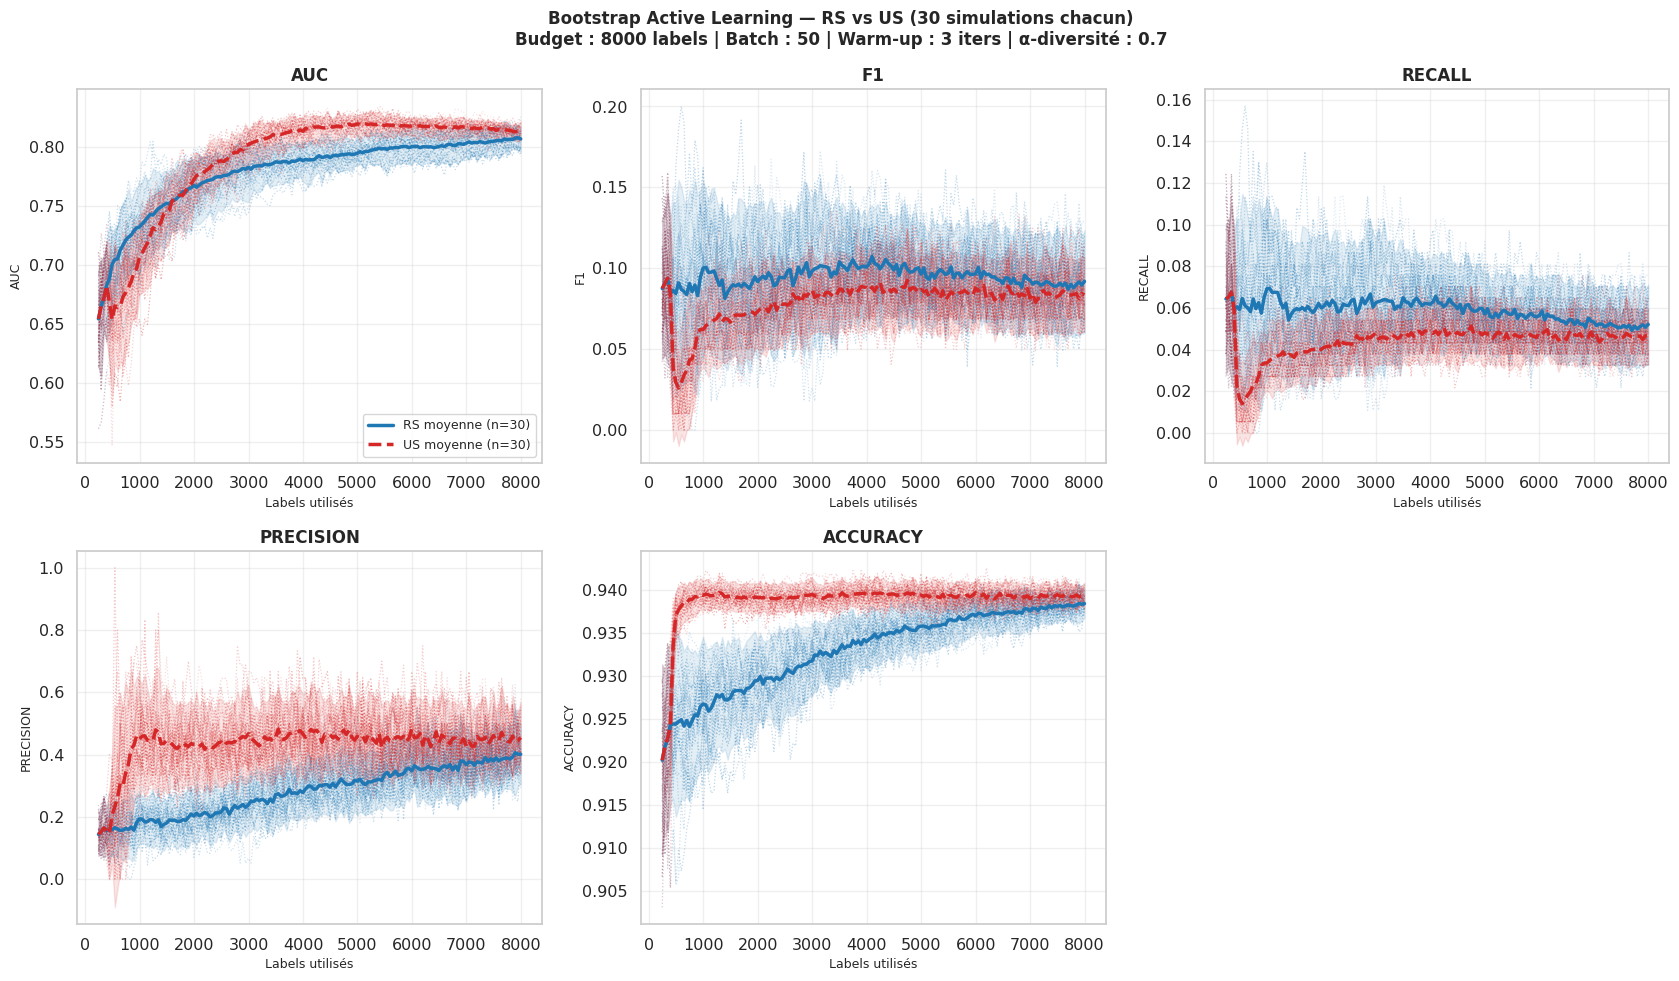

In [23]:
sns.set_theme(style='whitegrid', palette='deep', font_scale=1.05)

METRICS  = ['auc', 'f1', 'recall', 'precision', 'accuracy']
COL_RS   = '#1f77b4'   # bleu
COL_US   = '#d62728'   # rouge

# Transparence dégradée pour les trajectoires individuelles
alphas = np.linspace(0.12, 0.35, N_SIM)

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()

for i, metric in enumerate(METRICS):
    ax = axes[i]

    # ── Trajectoires individuelles ────────────────────────────────────────────
    for j, sim in enumerate(results_RS_all):
        df_sim = pd.DataFrame(sim['results'])
        ax.plot(
            df_sim['labels_used'], df_sim[f'{metric}_rs'],
            color=COL_RS, alpha=alphas[j], linewidth=0.9, linestyle=':'
        )
    for j, sim in enumerate(results_US_all):
        df_sim = pd.DataFrame(sim['results'])
        ax.plot(
            df_sim['labels_used'], df_sim[f'{metric}_us'],
            color=COL_US, alpha=alphas[j], linewidth=0.9, linestyle=':'
        )

    # ── IC 90% ────────────────────────────────────────────────────────────────
    if metric == 'auc':
        df_rs_agg = agg_rs
        df_us_agg = agg_us
        q05_rs, q95_rs = df_rs_agg['auc_q05'], df_rs_agg['auc_q95']
        q05_us, q95_us = df_us_agg['auc_q05'], df_us_agg['auc_q95']
    else:
        df_rs_agg = df_rs.groupby('labels_used')[metric].agg(['mean','std']).reset_index()
        df_us_agg = df_us.groupby('labels_used')[metric].agg(['mean','std']).reset_index()
        df_rs_agg.columns = ['labels_used', 'auc_mean', 'auc_std']
        df_us_agg.columns = ['labels_used', 'auc_mean', 'auc_std']
        q05_rs = df_rs_agg['auc_mean'] - 1.645 * df_rs_agg['auc_std'].fillna(0)
        q95_rs = df_rs_agg['auc_mean'] + 1.645 * df_rs_agg['auc_std'].fillna(0)
        q05_us = df_us_agg['auc_mean'] - 1.645 * df_us_agg['auc_std'].fillna(0)
        q95_us = df_us_agg['auc_mean'] + 1.645 * df_us_agg['auc_std'].fillna(0)

    ax.fill_between(df_rs_agg['labels_used'], q05_rs, q95_rs,
                    color=COL_RS, alpha=0.12, zorder=1)
    ax.fill_between(df_us_agg['labels_used'], q05_us, q95_us,
                    color=COL_US, alpha=0.12, zorder=1)

    # ── Moyennes ──────────────────────────────────────────────────────────────
    ax.plot(df_rs_agg['labels_used'], df_rs_agg['auc_mean'],
            color=COL_RS, linewidth=2.5, label=f'RS moyenne (n={N_SIM})', zorder=5)
    ax.plot(df_us_agg['labels_used'], df_us_agg['auc_mean'],
            color=COL_US, linewidth=2.5, linestyle='--',
            label=f'US moyenne (n={N_SIM})', zorder=5)

    ax.set_title(metric.upper(), fontsize=12, fontweight='bold')
    ax.set_xlabel('Labels utilisés', fontsize=9)
    ax.set_ylabel(metric.upper(), fontsize=9)
    ax.grid(True, alpha=0.3)

    if metric == 'auc':
        ax.legend(fontsize=9, loc='lower right')

fig.delaxes(axes[5])
fig.suptitle(
    f'Bootstrap Active Learning — RS vs US ({N_SIM} simulations chacun)\n'
    f'Budget : {LABEL_MAX} labels | Batch : {BATCH_SIZE} | '
    f'Warm-up : {WARMUP_ITERS} iters | α-diversité : {DIVERSITY_ALPHA}',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()

fname = f'{OUTPUT_DIR}bootstrap_RS_vs_US_{N_SIM}sims_{LABEL_MAX}labels.png'
plt.savefig(fname, dpi=150, bbox_inches='tight')
print(f'✓ Graphique sauvegardé : {fname}')
plt.show()

## 9. Sauvegarde des résultats

In [24]:
df_rs.to_csv(f'{OUTPUT_DIR}results_RS_bootstrap.csv', index=False)
df_us.to_csv(f'{OUTPUT_DIR}results_US_bootstrap.csv', index=False)
agg_rs.to_csv(f'{OUTPUT_DIR}results_RS_aggregated.csv', index=False)
agg_us.to_csv(f'{OUTPUT_DIR}results_US_aggregated.csv', index=False)

print('✓ Fichiers sauvegardés')
print('  → results_RS_bootstrap.csv   (format long, toutes les simulations RS)')
print('  → results_US_bootstrap.csv   (format long, toutes les simulations US)')
print('  → results_RS_aggregated.csv  (moyenne/IC par labels_used)')
print('  → results_US_aggregated.csv  (moyenne/IC par labels_used)')

✓ Fichiers sauvegardés
  → results_RS_bootstrap.csv   (format long, toutes les simulations RS)
  → results_US_bootstrap.csv   (format long, toutes les simulations US)
  → results_RS_aggregated.csv  (moyenne/IC par labels_used)
  → results_US_aggregated.csv  (moyenne/IC par labels_used)
